In [ ]:
#Part 1-Numpy Fundamentals
import numpy as np
#q1.1
a=np.linspace(0,20,100)
mean=np.mean(a)
median=np.median(a)
standard_deviation=np.std(a)
variance=np.var(a)
print("Mean:",mean)
print("Median:",median)
print("Standard Deviation:",standard_deviation)
print("Variance:",variance)
#q1.2
b=np.arange(1,37)
print("Initially:", np.shape(b))
c=b.reshape(4,9)
print("After reshaping:",np.shape(c))
d=c.flatten()
print("After flattening:",np.shape(d))


Mean: 10.0
Median: 10.0
Standard Deviation: 5.831529302570125
Variance: 34.00673400673401
Initially: (36,)
After reshaping: (4, 9)
After flattening: (36,)


In [ ]:
#Part2- Pandas & Data Wrangling
import pandas as pd
import seaborn as sns
df=sns.load_dataset('titanic')
#q2.1
print(df.head())
print(df.info())
print(df.describe())
#q2.2
print("")
#1)
for i in df.columns:
  if df[i].isnull().sum()>0:
    print(i, df[i].count(), df[i].isnull().sum()*100/len(df),"%")
#2)
df['age'] = df['age'].fillna(df.groupby('pclass')['age'].transform('mean'))
#3)
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])
#4)
df.drop('deck',axis=1,inplace=True)
#5)
print("")
print("Null values left:")
print("age",df['age'].isnull().sum())
print("embarked",df['embarked'].isnull().sum())




   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

Dropping the deck column is appropriate here because most of its values are null, around 77%. Filling so many null values isn't right because the column is probably less useful with context to the dataset. This makes it less important compared to other columns making it hard to extract any key insights.

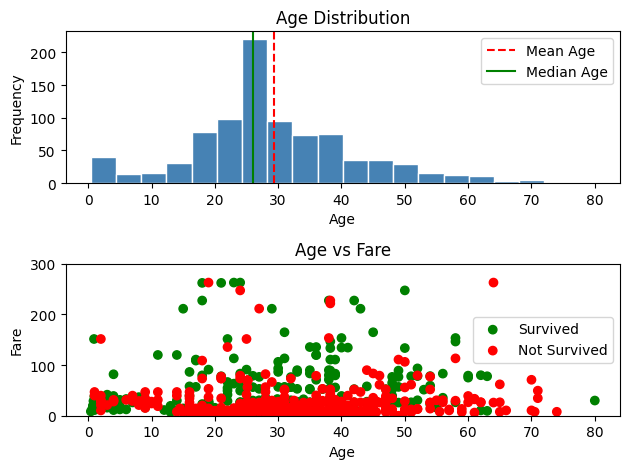

In [ ]:
#Part3-Matplotlib Visualiations
#3.1
import matplotlib.pyplot as plt
plt.subplot(2,1,1)
mean_age = df['age'].mean()
median_age = df['age'].median()
plt.hist(df['age'],bins=20,color='steelblue',edgecolor='white')
plt.axvline(mean_age,color='red',linestyle='--',label='Mean Age')
plt.axvline(median_age,color='green',label='Median Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.legend()
#3.2
plt.subplot(2,1,2)
survived=[]
not_survived=[]
survived_age=[]
survived_fare=[]
not_survived_age=[]
not_survived_fare=[]
for i in range(len(df)):
  if df.loc[i,'survived']==0:
    not_survived.append('red')
    not_survived_age.append(df.loc[i,'age'])
    not_survived_fare.append(df.loc[i,'fare'])
  else:
    survived.append('green')
    survived_age.append(df.loc[i,'age'])
    survived_fare.append(df.loc[i,'fare'])
plt.scatter(survived_age,survived_fare,c=survived,label='Survived')
plt.scatter(not_survived_age,not_survived_fare,c=not_survived,label='Not Survived')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare')
plt.legend()
plt.ylim(0,300)
plt.tight_layout()
plt.show()


The outliers have been removed by capping the y-axis limit to 300 because there were only few points that had values above 300. They are exceptions and we can't draw any meaningful insights if they are few, so for better readability, the limit was set.

In [ ]:
#Part4-Exploratory Data Analysis
#4.1
df2=pd.read_csv("advertising.csv")
print(df2.shape)
print(df2.dtypes)
print(df2.isnull().sum())
print(df2.describe())

(200, 4)
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


Range of TV=295.7 (large spread: std=85.9 approx)
Range of Radio=49.6 (moderate spread: std=14.9 approx)
Range of Newspaper=113.7 moderate spread: std=21.8 approx with some extreme outliers
Range of Sales=26.4 (relatively small spread: std=5.3 approx i.e. most values are clustered around the mean value)


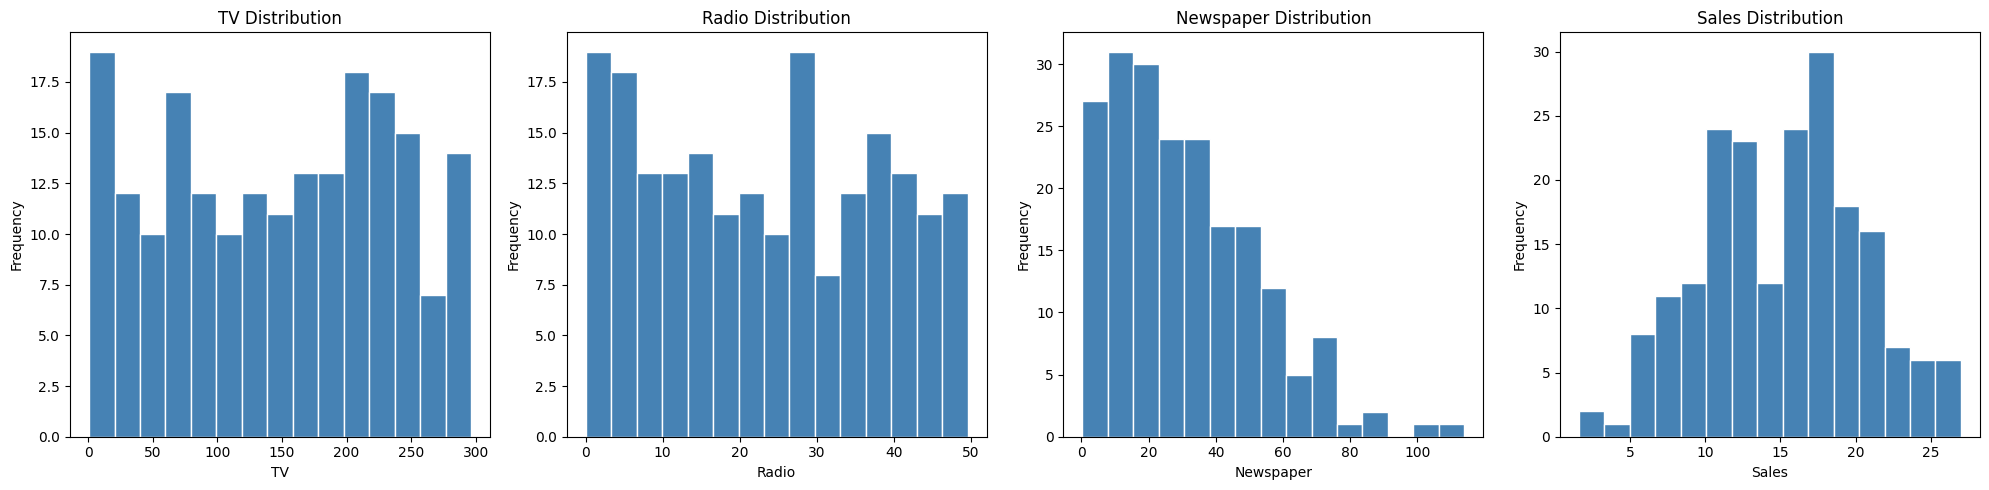

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
plt.hist(df2['TV'],bins=15,color='steelblue',edgecolor='white')
plt.xlabel('TV')
plt.ylabel('Frequency')
plt.title('TV Distribution')
plt.subplot(1,4,2)
plt.hist(df2['Radio'],bins=15,color='steelblue',edgecolor='white')
plt.xlabel('Radio')
plt.ylabel('Frequency')
plt.title('Radio Distribution')
plt.subplot(1,4,3)
plt.hist(df2['Newspaper'],bins=15,color='steelblue',edgecolor='white')
plt.xlabel('Newspaper')
plt.ylabel('Frequency')
plt.title('Newspaper Distribution')
plt.subplot(1,4,4)
plt.hist(df2['Sales'],bins=15,color='steelblue',edgecolor='white')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Sales Distribution')
plt.tight_layout()
plt.show()

From visual inspection, I can apparently see some outliers, particularly in the newspaper distribution. In the range 80-100, the frequency is very small that is only few advertising campaigns spent around 80–100 units on newspaper advertisements. Same can be seen in 0-5 range for sales distribution, only a few observations record very low sales values.

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


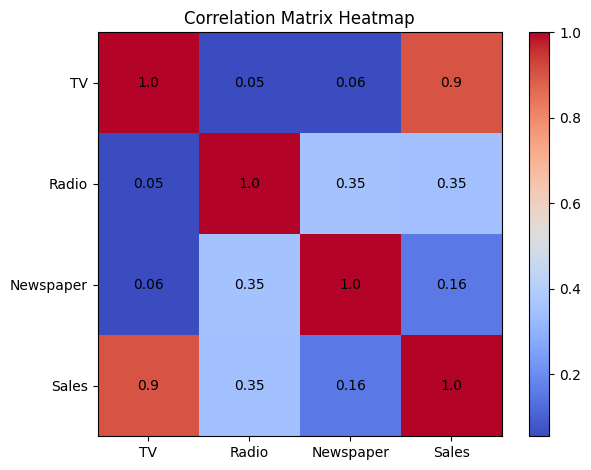

In [ ]:
#4.2
corr_matrix = df2.corr()
print(corr_matrix)
plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i,round(corr_matrix.iloc[i, j], 2), ha='center', va='center', color='black')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()


TV is most correlated with Sales(0.9). This implies that advertisements in TV have the strongest positive relationship with Sales.

TV isn't correlated with Radio as 0.05 is almost 0 that indicates almost no linear relationship between them.

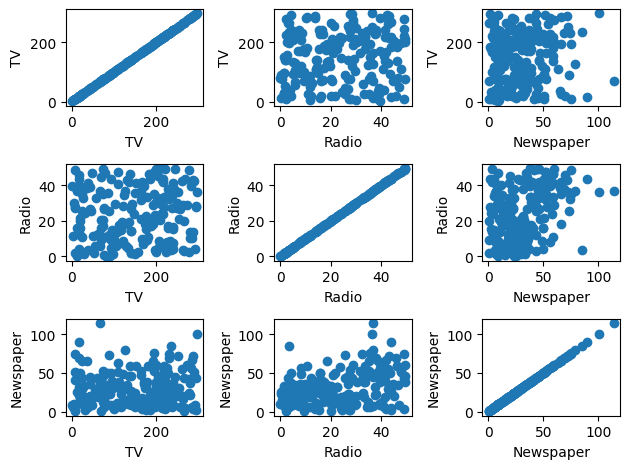

In [ ]:
plt.subplot(3,3,1)
plt.scatter(df2['TV'], df2['TV'])
plt.xlabel('TV')
plt.ylabel('TV')
plt.subplot(3,3,2)
plt.scatter(df2['Radio'], df2['TV'])
plt.xlabel('Radio')
plt.ylabel('TV')
plt.subplot(3,3,3)
plt.scatter(df2['Newspaper'], df2['TV'])
plt.xlabel('Newspaper')
plt.ylabel('TV')
plt.subplot(3,3,4)
plt.scatter(df2['TV'], df2['Radio'])
plt.xlabel('TV')
plt.ylabel('Radio')
plt.subplot(3,3,5)
plt.scatter(df2['Radio'], df2['Radio'])
plt.xlabel('Radio')
plt.ylabel('Radio')
plt.subplot(3,3,6)
plt.scatter(df2['Newspaper'], df2['Radio'])
plt.xlabel('Newspaper')
plt.ylabel('Radio')
plt.subplot(3,3,7)
plt.scatter(df2['TV'], df2['Newspaper'])
plt.xlabel('TV')
plt.ylabel('Newspaper')
plt.subplot(3,3,8)
plt.scatter(df2['Radio'], df2['Newspaper'])
plt.xlabel('Radio')
plt.ylabel('Newspaper')
plt.subplot(3,3,9)
plt.scatter(df2['Newspaper'], df2['Newspaper'])
plt.xlabel('Newspaper')
plt.ylabel('Newspaper')
plt.tight_layout()
plt.show()

TV->Sales
Slope: 0.055726018950058714
Intercept: 6.993686960994356
Radio->Sales
Slope: 0.12399163640539278
Intercept: 11.934139103071896
Newspaper->Sales
Slope: 0.03478639878292218
Intercept: 13.842399973101667


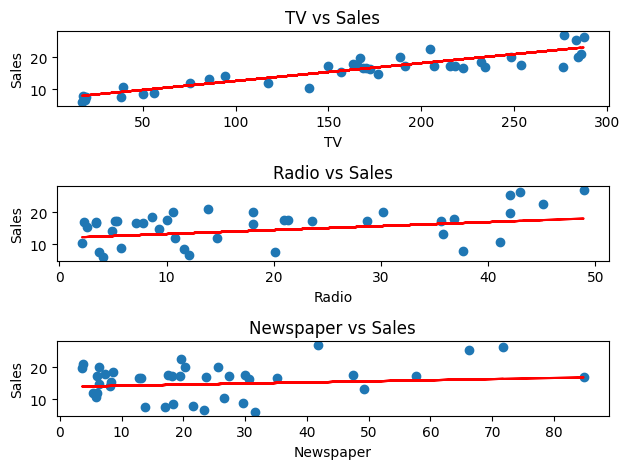

MSE(TV->Sales) 5.459799471482253
MSE(Radio->Sales) 24.307765815029036
MSE(Newspaper->Sales) 26.776485219741126


In [ ]:
#Part5-Linear Regression
#5.1-Scratch Implementation: Simple Linear Regression
train=df2.iloc[:160]
test=df2.iloc[160:]
print("TV->Sales")
n1=train['TV'].values
y=train['Sales'].values
y_mean=y.mean()
sum1=0
sum2=0
prod1=1
prod2=1
for i in range(len(n1)):
  prod1=n1[i]-n1.mean()
  prod2=y[i]-y.mean()
  sum1=sum1+(prod1*prod2)
  sum2=sum2+(prod1*prod1)
m1=sum1/sum2
c1=y_mean-(m1*n1.mean())
print("Slope:",m1)
print("Intercept:",c1)
print("Radio->Sales")
n2=train['Radio'].values
sum1=0
sum2=0
prod1=1
prod2=1
for i in range(len(n2)):
  prod1=n2[i]-n2.mean()
  prod2=y[i]-y.mean()
  sum1=sum1+(prod1*prod2)
  sum2=sum2+(prod1*prod1)
m2=sum1/sum2
c2=y_mean-(m2*n2.mean())
print("Slope:",m2)
print("Intercept:",c2)
print("Newspaper->Sales")
n3=train['Newspaper'].values
sum1=0
sum2=0
prod1=1
prod2=1
for i in range(len(n3)):
  prod1=n3[i]-n3.mean()
  prod2=y[i]-y.mean()
  sum1=sum1+(prod1*prod2)
  sum2=sum2+(prod1*prod1)
m3=sum1/sum2
c3=y_mean-(m3*n3.mean())
print("Slope:",m3)
print("Intercept:",c3)
#Linear Regression: TV->Sales
plt.subplot(3,1,1)
y_test=test['Sales'].values
x1=test['TV'].values
x2=test['Radio'].values
x3=test['Newspaper'].values
y1_pred=m1*x1+c1
plt.scatter(x1,y_test)
plt.plot(x1,y1_pred,color='red')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV vs Sales')
plt.subplot(3,1,2)
y2_pred=m2*x2+c2
plt.scatter(x2,y_test)
plt.plot(x2,y2_pred,color='red')
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.title('Radio vs Sales')
plt.subplot(3,1,3)
y3_pred=m3*x3+c3
plt.scatter(x3,y_test)
plt.plot(x3,y3_pred,color='red')
plt.xlabel('Newspaper')
plt.ylabel('Sales')
plt.title('Newspaper vs Sales')
plt.tight_layout()
plt.show()
MSE1=np.mean((y_test-y1_pred)**2)
MSE2=np.mean((y_test-y2_pred)**2)
MSE3=np.mean((y_test-y3_pred)**2)
print("MSE(TV->Sales)",MSE1)
print("MSE(Radio->Sales)",MSE2)
print("MSE(Newspaper->Sales)",MSE3)

Slope: [0.05548294]
Intercept: 7.007108428241848


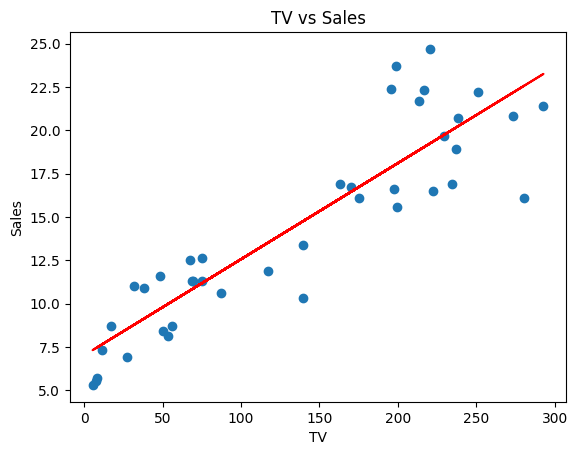

In [ ]:
#5.2-SKlearn Implementation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X=df2[['TV']]
y=df2['Sales']
X_train1, X_test1, y_train1, y_test1=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train1, y_train1)
y_pred1=model.predict(X_test1)
print("Slope:",model.coef_)
print("Intercept:",model.intercept_)
plt.scatter(X_test1,y_test1)
plt.plot(X_test1,y_pred1,color='red')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('TV vs Sales')
plt.show()


The values of coefficient and intercept are actually close. For TV->Sales linear regression,

by Sklearn, coeff=0.0554, by manual implementation, coeff=0.0557
by Sklearn, intercept=7.007, by manual implementation, intercept=6.993

There is a small difference between the two because the split was done differently. In Sklearn, the split is done randomly that is the train set got 160 random rows but in manual implementation, it got first 160 rows. Random splitting can provide a more representative sample of the dataset, which helps ensure the model is not biased by any ordering in the data.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_train_pred=model.predict(X_train1)
y_test_pred=model.predict(X_test1)
train_mae=mean_absolute_error(y_train1, y_train_pred)
train_mse=mean_squared_error(y_train1, y_train_pred)
train_rmse=np.sqrt(train_mse)
train_r2=r2_score(y_train1, y_train_pred)
test_mae=mean_absolute_error(y_test1, y_test_pred)
test_mse=mean_squared_error(y_test1, y_test_pred)
test_rmse=np.sqrt(test_mse)
test_r2=r2_score(y_test1, y_test_pred)
print("TRAIN METRICS")
print("MAE:", train_mae)
print("MSE:", train_mse)
print("RMSE:", train_rmse)
print("R2:", train_r2)
print("\nTEST METRICS")
print("MAE:", test_mae)
print("MSE:", test_mse)
print("RMSE:", test_rmse)
print("R2:", test_r2)

TRAIN METRICS
MAE: 1.8005092256620792
MSE: 4.998442356450173
RMSE: 2.235719650683013
R2: 0.8134866044709264

TEST METRICS
MAE: 1.9502948931650088
MSE: 6.101072906773963
RMSE: 2.470035001123256
R2: 0.802561303423698


The model is well-fit because the R2 scores and MAE,MSE,RMSE are all very similar. An overfit model would have had a higher R2 score for train data and lower for test, but this isn't happening with this model. An underfit model would show big errors but that too isn't happening. Hence, the model is relatively well-fit.

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  

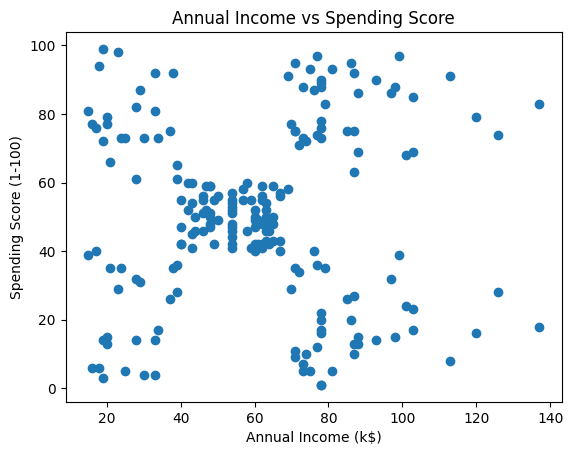

In [ ]:
#Part6-K Means Clustering
#6.1-Data Exploration
df3=pd.read_csv("Mall_Customers.csv")
print(df3.head())
print(df3.info())
print(df3.describe())
plt.scatter(df3['Annual Income (k$)'], df3['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.show()


Yeah, visually I can see 5 groupings can be done.

In [ ]:
#6.2 Apply K-Means
from sklearn.cluster import KMeans
X=df3[['Annual Income (k$)', 'Spending Score (1-100)']]
k_means=KMeans(n_clusters=5, random_state=42)
df3['Cluster'] = k_means.fit_predict(X)
centroids=pd.DataFrame(k_means.cluster_centers_, columns=['X-coordinate', 'Y-coordinate'])
print(centroids)
cluster_wise=df3.groupby('Cluster').agg({'CustomerID':'count','Annual Income (k$)':'mean',
'Spending Score (1-100)':'mean'})
cluster_wise.columns=['Count of Customers','Mean Annual Income','Mean Spending Score']
print(cluster_wise)

   X-coordinate  Y-coordinate
0     55.296296     49.518519
1     86.538462     82.128205
2     25.727273     79.363636
3     88.200000     17.114286
4     26.304348     20.913043
         Count of Customers  Mean Annual Income  Mean Spending Score
Cluster                                                             
0                        81           55.296296            49.518519
1                        39           86.538462            82.128205
2                        22           25.727273            79.363636
3                        35           88.200000            17.114286
4                        23           26.304348            20.913043


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


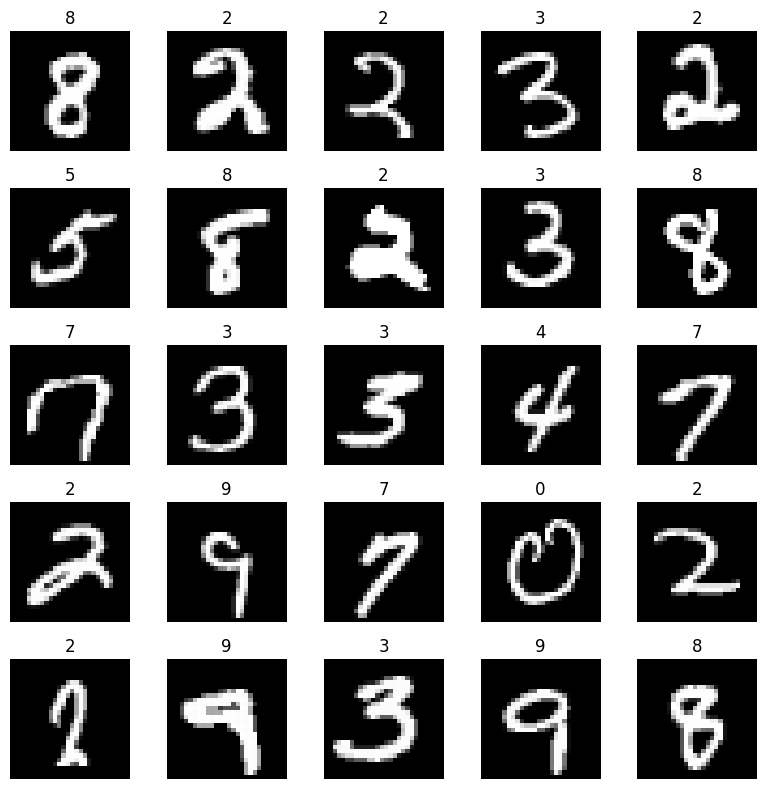

In [ ]:
#Part7-Neural Networks on MNIST
#7.1-Data Loading and Preprocessing
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
X_train=X_train/255.0
X_test=X_test/255.0
fig, axes=plt.subplots(5, 5, figsize=(8, 8))
img_random=np.random.randint(0, X_train.shape[0], 25)
for ax, idx in zip(axes.flat, img_random):
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(y_train[idx])
    ax.axis('off')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9221 - loss: 0.2639 - val_accuracy: 0.9568 - val_loss: 0.1392
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9665 - loss: 0.1129 - val_accuracy: 0.9658 - val_loss: 0.1136
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9767 - loss: 0.0763 - val_accuracy: 0.9693 - val_loss: 0.0952
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9821 - loss: 0.0583 - val_accuracy: 0.9716 - val_loss: 0.0952
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9855 - loss: 0.0448 - val_accuracy: 0.9695 - val_loss: 0.1056
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9871 - loss: 0.0385 - val_accuracy: 0.9736 - val_loss: 0.0959
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9894 - loss: 0.0321 - val_accuracy: 0.9731 - val_loss: 0.0998
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9913 - loss: 0.02

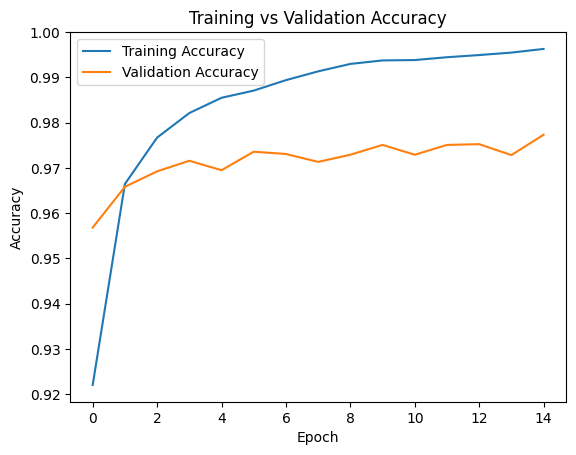

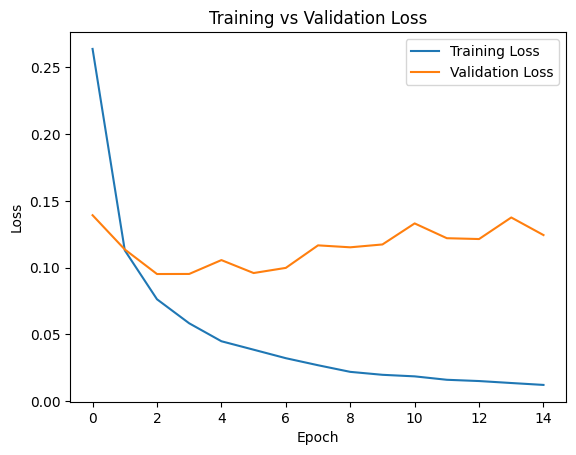

In [ ]:
#7.2-Feedforward Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
model = Sequential([Flatten(input_shape=(28, 28)),Dense(128, activation='relu'),
Dense(64, activation='relu'), Dense(10, activation='softmax')])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
print(model.summary())
history = model.fit(X_train,y_train,epochs=15,validation_split=0.2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

Total parameters used are 109,386 as

[(784+1)*128 + (128+1)*64 + (64+1)*10 = 100480 + 8256 + 650 = 109386]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9787 - loss: 0.1125
Test Loss: 0.11254861950874329
Test Accuracy: 0.9786999821662903
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


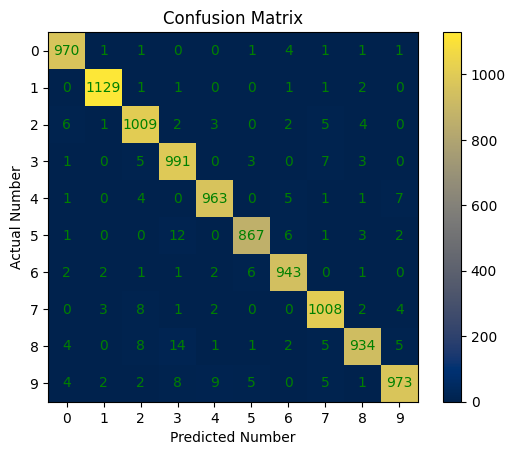

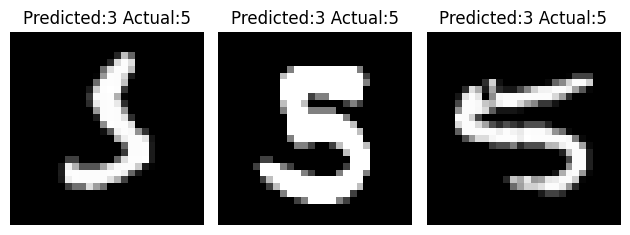

In [ ]:
#7.3-Evaluation and Error Analysis
from sklearn.metrics import confusion_matrix
test_loss,test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
y_pred_probability=model.predict(X_test)
y_pred=np.argmax(y_pred_probability, axis=1)
confusion=confusion_matrix(y_test, y_pred)
plt.imshow(confusion, cmap='cividis')
plt.colorbar()
plt.xticks(np.arange(10))
plt.yticks(np.arange(10))
plt.xlabel("Predicted Number")
plt.ylabel("Actual Number")
plt.title("Confusion Matrix")
for i in range(10):
    for j in range(10):
        plt.text(j, i, confusion[i, j], ha='center', va='center', color='green')
plt.show()
wrong_img1=np.where((y_test == 5)&(y_pred == 3))[0]
for i in range(3):
  idx=wrong_img1[i]
  plt.subplot(1,3,i+1)
  plt.imshow(X_test[idx], cmap='gray')
  plt.title("Predicted:3 Actual:5")
  plt.axis('off')
plt.tight_layout()
plt.show()

3 and 5 were most confused images as from the heatmap we can see that the model predicted 17 actual 5s wrongly as 3. From the examples, this could be because the model has perhaps learnt that 3 contains two flpped 'c's. 5 also has similar flipped 'c' at the bottom, so whenever images of 5 came that doesn't have well defined right angle at top and either misses it or includes the 'c' type figure, it considered it to be 3.

In [ ]:
#7.4-Convolution Neural Network(CNN)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
X_train_CNN=X_train.reshape(-1,28,28,1)
X_test_CNN=X_test.reshape(-1,28,28,1)
cnn_model = Sequential([Conv2D(32, kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
MaxPooling2D(pool_size=(2,2)),Conv2D(64,kernel_size=(3,3),activation='relu'),
MaxPooling2D(pool_size=(2,2)),Flatten(),Dense(128, activation='relu'),Dense(10, activation='softmax')])
cnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
print(cnn_model.summary())
cnn_history = cnn_model.fit(X_train_CNN,y_train,epochs=10,validation_split=0.2)
test_loss_CNN, test_acc_CNN = cnn_model.evaluate(X_test_CNN, y_test)
print("Final Test Accuracy:", test_acc_CNN)
comparison=pd.DataFrame({'Model': ['Feedforward NN', 'CNN'],
'Parameters': [109386, 225034],'Train Acc': [history.history['accuracy'][-1],
cnn_history.history['accuracy'][-1]], 'Val Acc': [history.history['val_accuracy'][-1],
cnn_history.history['val_accuracy'][-1]],'Test Acc': [test_accuracy, test_acc_CNN],
'Epochs': [15, 10]})
print(comparison)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.9541 - loss: 0.1467 - val_accuracy: 0.9729 - val_loss: 0.0876
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9851 - loss: 0.0467 - val_accuracy: 0.9888 - val_loss: 0.0386
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.9895 - loss: 0.0314 - val_accuracy: 0.9880 - val_loss: 0.0411
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.9926 - loss: 0.0221 - val_accuracy: 0.9898 - val_loss: 0.0374
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 77s 34ms/step - accuracy: 0.9945 - loss: 0.0169 - val_accuracy: 0.9907 - val_loss: 0.0348
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9959 - loss: 0.0128 - val_accuracy: 0.9891 - val_loss: 0.0494
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9964 - loss: 0.0109 - val_accuracy: 0.9908 - val_loss: 0.0378
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9

There are 225034 parameters now around double the parameteres in Feedforward Neural Network.

CNNs outperform dense neural networks on image data because Convolution filters learn local patterns such as edges, curves, corners, and textures directly from neighboring pixels. This helps it to recognise shapes and digit structures more effectively unlike dense networks which flatten images into 1D vectors.